In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

<h1>CUP - LinearSVR</h1>
<p>Exploring the cup dataset with LinearSVR.</p>
<hr/>

In [3]:
import importlib

import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR, LinearSVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, \
    r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict, KFold
import cup_common as cc
import svm_common as sc
import cross_common as cr

In [3]:
importlib.reload(sc)
importlib.reload(cc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h2>Preparation</h2>

<h3>Hyperparameters</h3>

In [43]:
from sklearn.svm import LinearSVR

# We only test SVR
pipe_default = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", MultiOutputRegressor(LinearSVR())),
])


param_grid_default = {
    "model__estimator__C": np.logspace(-4, 3, 8),
    # The epsilon_insensitive loss (standard SVR) is the L1 loss (MAE),
    # while the squared_epsilon_insensitive loss is the L2 loss (MSE).
    #"model__estimator__loss": ["epsilon_insensitive"],
    #"model__estimator__dual": [True, False],
    "model__estimator__max_iter": [20000]
}

# Common scoring
default_metric = "mae"
scoring = cr.common_scoring(default_metric)

# Common CV fold strategy
outer_cv = cr.common_fold_strategy()


<h3>Data Loading</h3>

In [5]:
df_train, df_test = cc.load_set()
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)
features_names = X_tr.columns
cr.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,15,11
2,Class values,[],[]
3,Class balance,[],[]


<h3>Baseline</h3>

In [6]:
importlib.reload(cr)
model_baseline = cr.model_baseline(X_tr, y_tr, outer_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.79302825927734
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-36.10307312 -34.5480423  -35.62013626 -35.9157486  -36.77814102]


<h3>Best Model</h3>

In [44]:
# Perform a grid search
gs = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_default,
    cv = outer_cv,
    scoring = scoring,
    error_score="raise",
    n_jobs = -1 # use all available cores
)

# Fit TR features and labels into grid
gs.fit(X_tr, y_tr)
best_estimator = gs.best_estimator_
best_model, best_params = cr.extract_best_pipeline_metrics_from_grid(gs)
cr.grid_introspection(gs)

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: Co

Grid summary
----------------------------------------
Total model explored: 8  splits: 5
Best params: {'model__estimator__C': np.float64(0.1), 'model__estimator__max_iter': 20000}
Best score: -11.707408182363324
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=LinearSVR(C=np.float64(0.1),
                                                          max_iter=20000)))])


/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: Co

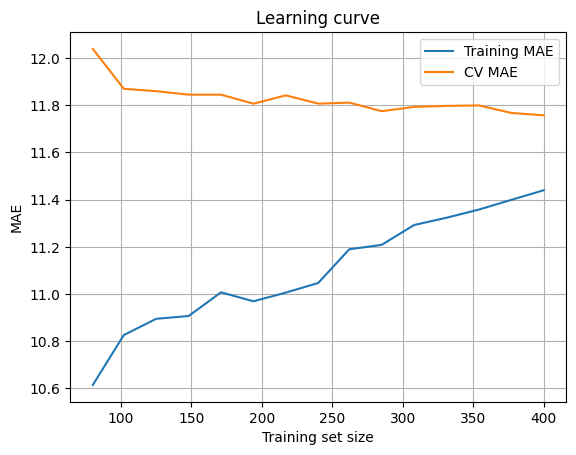

In [21]:
importlib.reload(cr)
cr.plot_learning_curve(best_model, X_tr, y_tr, outer_cv, scoring=scoring)

<h2>Model estimation</h2>
<p>The model is estimated trough two different approaches: non nested and nested KFold.</p>
<hr/>

<h3>Non nested Cross Validation</h3>

In [22]:
from sklearn import clone

runner = cr.SklearnRegressorRunner(clone(gs.best_estimator_).set_params(**gs.best_params_))
kf_result = cr.kfold(runner, X_tr, y_tr, outer_cv)

  
Perform fold: 1, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 201.3825
Validation RMSE | 14.1909
Validation MEE  | 25.5964
Validation MAE  | 11.7644
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 198.3107
Validation RMSE | 14.0823
Validation MEE  | 25.3088
Validation MAE  | 11.6589
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 3, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 187.1357
Validation RMSE | 13.6798
Validation MEE  | 25.0197
Validation MAE  | 11.4600
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 4, train size: 400, val size: 100
 
Fold 

In [23]:
best_idx = gs.best_index_
mean_score = gs.cv_results_["mean_test_score"][best_idx]
std_score  = gs.cv_results_["std_test_score"][best_idx]
print(f"Best CV grid score: {mean_score:.4f} ± {std_score:.4f}")
mean, std = cr.extract_mean_std(kf_result, f"fold_vl_{default_metric}")
print(f"Best CV func score: {mean:.4f} ± {std:.4f}")

Best CV grid score: -11.6696 ± 0.1160
Best CV func score: 11.6696 ± 0.1160


<h3>Nested Cross Validation</h3>

In [24]:
importlib.reload(cr)

inner_cv = cr.common_fold_strategy(n_split=3)
outer_cv = outer_cv

gs_inner = GridSearchCV(
    pipe_default,
    param_grid=param_grid_default,
    scoring=scoring,
    cv=inner_cv,
    n_jobs=-1,
    return_train_score=True
)
nested_runner = cr.SklearnNestedRegressorRunner(gs_inner)
nested_result = cr.kfold(nested_runner, X_tr, y_tr, outer_cv)

  
Perform fold: 1, train size: 400, val size: 100


/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: Co

Grid summary
----------------------------------------
Total model explored: 32  splits: 3
Best params: {'model__estimator__C': np.float64(0.01), 'model__estimator__dual': False, 'model__estimator__loss': 'squared_epsilon_insensitive', 'model__estimator__max_iter': 5000}
Best score: -11.632260284344534
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=LinearSVR(C=np.float64(0.01),
                                                          dual=False,
                                                          loss='squared_epsilon_insensitive',
                                                          max_iter=5000)))])
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 201.3825
Validation RMSE | 14.1909
Validation MEE  | 25.5964
Validation MAE  | 11.7644
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 2, train size:

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: Co

Grid summary
----------------------------------------
Total model explored: 32  splits: 3
Best params: {'model__estimator__C': np.float64(0.01), 'model__estimator__dual': False, 'model__estimator__loss': 'squared_epsilon_insensitive', 'model__estimator__max_iter': 5000}
Best score: -11.6570059744203
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=LinearSVR(C=np.float64(0.01),
                                                          dual=False,
                                                          loss='squared_epsilon_insensitive',
                                                          max_iter=5000)))])
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 198.3107
Validation RMSE | 14.0823
Validation MEE  | 25.3088
Validation MAE  | 11.6589
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 3, train size: 4

...

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: Co

Grid summary
----------------------------------------
Total model explored: 32  splits: 3
Best params: {'model__estimator__C': np.float64(0.01), 'model__estimator__dual': False, 'model__estimator__loss': 'squared_epsilon_insensitive', 'model__estimator__max_iter': 5000}
Best score: -11.750290069000599
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=LinearSVR(C=np.float64(0.01),
                                                          dual=False,
                                                          loss='squared_epsilon_insensitive',
                                                          max_iter=5000)))])
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 195.4299
Validation RMSE | 13.9796
Validation MEE  | 25.8202
Validation MAE  | 11.7890
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 5, train size:

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: Co

Grid summary
----------------------------------------
Total model explored: 32  splits: 3
Best params: {'model__estimator__C': np.float64(0.01), 'model__estimator__dual': False, 'model__estimator__loss': 'squared_epsilon_insensitive', 'model__estimator__max_iter': 5000}
Best score: -11.669410960715425
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=LinearSVR(C=np.float64(0.01),
                                                          dual=False,
                                                          loss='squared_epsilon_insensitive',
                                                          max_iter=5000)))])
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 195.5315
Validation RMSE | 13.9833
Validation MEE  | 25.7999
Validation MAE  | 11.6757
Train           | samples: 400
Validation      | samples: 100


/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: Co

<p>This plot shows the evolution of training and cross-validation errors as the training set size increases. The learning curve helps assess whether the model suffers from underfitting or overfitting and whether performance is limited by model capacity or by intrinsic noise in the data.</p>

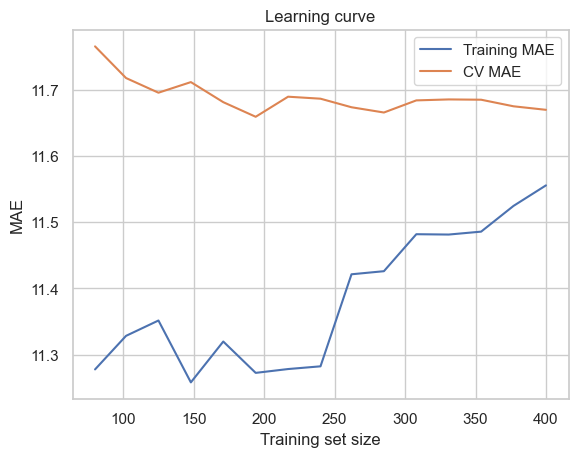

In [33]:
importlib.reload(cr)
cr.plot_learning_curve(best_estimator, X_tr, y_tr, outer_cv, scoring=gs.scoring)

<h3>Results</h3>
<hr/>

<p>We expect that non nested KFold result has more optimistic metrics in respect to nested KFold.</p>

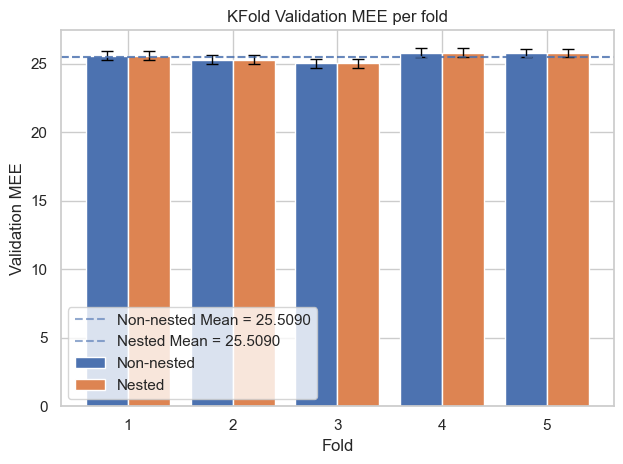

In [26]:
cr.plot_kfold_mee(kf_result, nested_result)

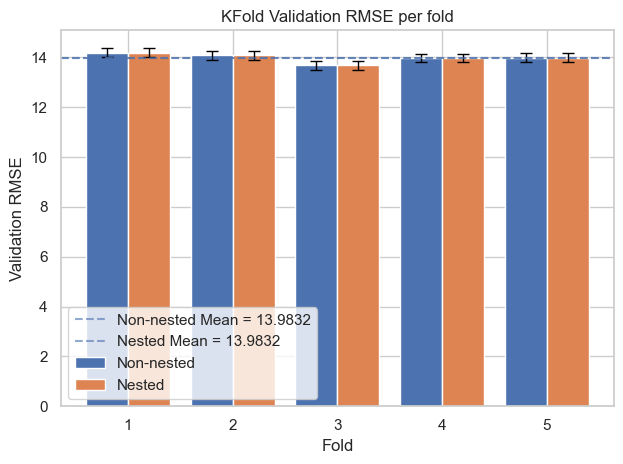

In [27]:
cr.plot_kfold_rmse(kf_result,nested_result)

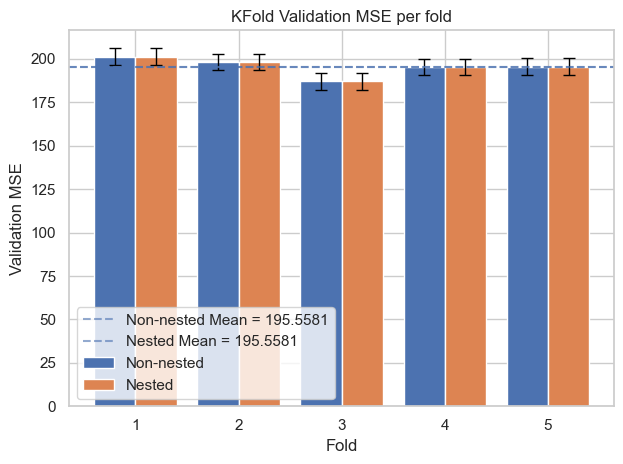

In [28]:
cr.plot_kfold_mse(kf_result,nested_result)

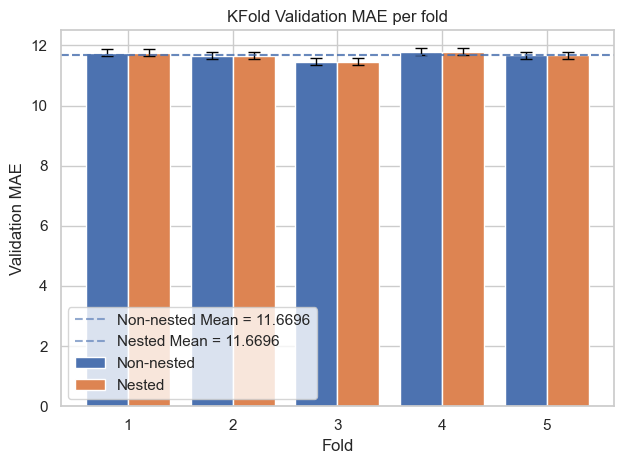

In [29]:
cr.plot_kfold_mae(kf_result,nested_result)

In [30]:
cr.kfold_regression_table(kf_result, derive_rmse=True)

,TR_MEE,VL_MEE,Gap(TR-VL),TR_RMSE,VL_RMSE
Fold,,,,,
1,25.261299,25.596377,0.335077,5.026062,5.059286
2,25.365053,25.308769,-0.056284,5.036373,5.030782
3,25.371628,25.019749,-0.351879,5.037026,5.001974
4,25.172701,25.820187,0.647486,5.017240,5.081357
5,25.198705,25.799936,0.601231,5.019831,5.079364
MEAN,25.273877,25.509003,0.235126,5.027306,5.050553
STD,0.092079,0.342263,0.431149,0.009157,0.033934


<h2>Test predictions</h2>
<hr/>

In [31]:
unfitted_model = runner.new_model()
fitted_model = runner.fit(unfitted_model, X_tr, y_tr)
y_pred = runner.predict(fitted_model, X_ts)

In [32]:
print(y_pred)

[[  1.03695093  -0.18327186   6.52566105  -7.3231024 ]
 [ -1.83851485  -0.16802125 -26.67713804  26.50891628]
 [ -1.82154205   0.37463048  -4.94607565   6.50234588]
 ...
 [  1.18864378   0.08751041  14.28337773 -14.4556838 ]
 [ -1.35013824   0.1049025  -21.79109129  23.07148969]
 [  1.52825076  -0.2669893    5.45474056  -7.26556657]]


<hr/>